In [1]:
import pandas as pd
import numpy as np
from typing import List, Dict, Any
from scipy.stats import pearsonr 

from src.build_network import ResIN
import networkx as nx

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats("retina")
from adjustText import adjust_text

import yaml
with open("../../src/configs.yml", "r") as configs:
    configs = yaml.safe_load(configs)

ROOTPATH = configs["ROOTPATH"]
ROOTPATH2 = configs["ROOTPATH2"]
OUTPATH = "../../output/results-summary-091924/"

print(configs)

{'ROOTPATH': '/Users/yijingch/Documents/GITHUB/broken-egg-polarization/', 'GITHUBPATH': '/Users/yijingch/Documents/GITHUB/', 'ROOTPATH2': '/Users/yijingch/Dropbox/CSS 2023 Attitude Networks/ANES/Cumulative'}


## Testing different levels of sorting

In [44]:
N = 1000
df = pd.DataFrame()
df["A"] = [1]*400 + [2]*400 + [3]*400
df["B"] = [1]*100 + [2]*200 + [3]*100 + [1]*150 + [2]*100 + [3]*150 + [1]*150 + [2]*200 + [3]*50

pearsonr(df["A"], df["B"])

NODE_COLS = ["A","B"]


In [45]:
resin = ResIN(df=df, node_cols=NODE_COLS)
resin.make_graph(square_corr=False, remove_nan=True)
resin.compute_covariates()
resin.adjust_coordinates()
resin.get_item_size()
resin.set_edge_distance()

In [46]:
resin.edge_weights

{('B:1', 'A:1'): -0.125,
 ('B:1', 'A:2'): 0.0625,
 ('B:1', 'A:3'): 0.0625,
 ('A:1', 'B:3'): 0.0,
 ('A:1', 'B:2'): 0.11952286093343936,
 ('B:3', 'A:2'): 0.2041241452319315,
 ('B:3', 'A:3'): -0.2041241452319315,
 ('A:2', 'B:2'): -0.23904572186687872,
 ('A:3', 'B:2'): 0.11952286093343936}

In [47]:
nx.betweenness_centrality(resin.g, weight="distance")

{'B:1': 0.6000000000000001,
 'A:2': 0.4,
 'A:3': 0.6000000000000001,
 'A:1': 0.0,
 'B:2': 0.4,
 'B:3': 0.0}

/Users/yijingch/opt/anaconda3/envs/broken-egg/lib/python3.9/site-packages/networkx/drawing/nx_pylab.py:437: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  node_collection = ax.scatter(


{'B:1': Text(-0.2599724655947308, 3.890881657475088e-17, 'B:1'),
 'A:2': Text(-0.8220651631657161, -1.5277061805324716e-16, 'A:2'),
 'A:3': Text(0.32275684978757485, 1.0899380163542535e-16, 'A:3'),
 'A:1': Text(1.1282582023819316, 1.0692219990144454e-16, 'A:1'),
 'B:2': Text(0.7529791996267986, 1.3097053526579555e-16, 'B:2'),
 'B:3': Text(-1.1219566230358584, -1.5590816231888909e-16, 'B:3')}

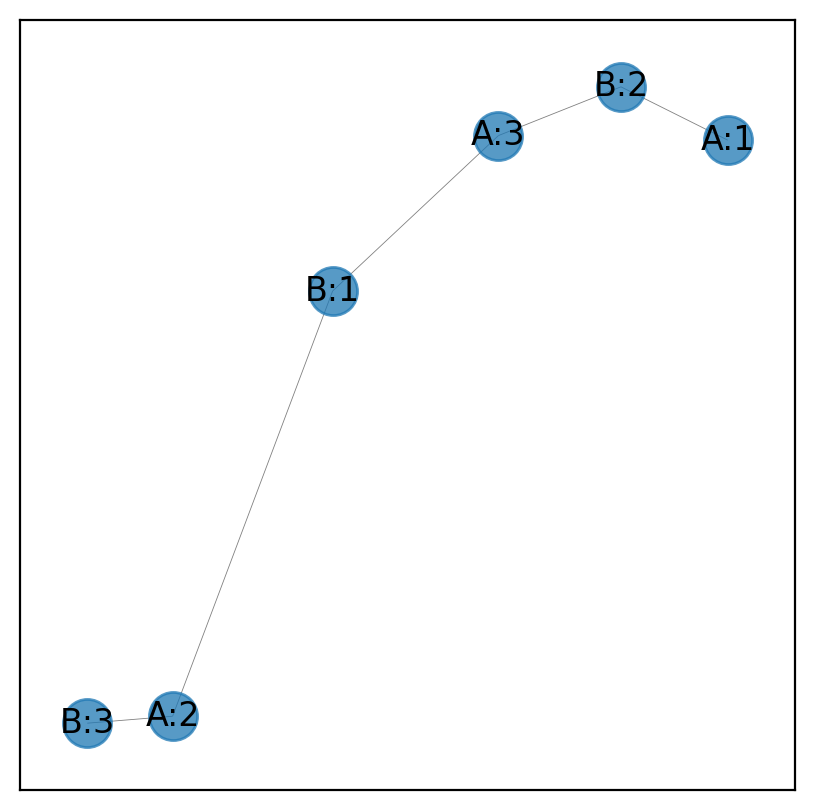

In [48]:
fig,ax = plt.subplots(figsize=(5,5))
nodes_plot = nx.draw_networkx_nodes(
        resin.g, ax=ax, 
        pos=resin.pos_new, 
        cmap="RdBu_r", 
        alpha=.75, label=False) 
edges_plot = nx.draw_networkx_edges(
resin.g, ax=ax, edge_color="grey", pos=resin.pos_new, width=.3,
)
nx.draw_networkx_labels(resin.g, ax=ax, pos=resin.pos_new)

## Testing node-level differences

In [52]:
N = 200
df = pd.DataFrame()
df["A"] = [1]*100 + [2]*100 + [3]*100
df["C"] = [1]*25 + [2]*50 + [3]*25 + [1]*30 + [2]*50 + [3]*20 + [1]*50 + [2]*25 + [3]*25
df["B"] = [1]*100 + [2]*100 + [3]*100

print(pearsonr(df["A"], df["B"]))
print(pearsonr(df["A"], df["C"]))
print(pearsonr(df["B"], df["C"]))

NODE_COLS = ["A", "B", "C"]
# NODE_COLS = ["A", "C"]

PearsonRResult(statistic=1.0, pvalue=0.0)
PearsonRResult(statistic=-0.1352174693504961, pvalue=0.019127918846587832)
PearsonRResult(statistic=-0.1352174693504961, pvalue=0.019127918846587832)


In [53]:
resin = ResIN(df=df, node_cols=NODE_COLS)
resin.make_graph(square_corr=False, remove_nan=True)
resin.compute_covariates()
resin.adjust_coordinates()
resin.get_item_size()
resin.set_edge_distance()
resin.edge_weights

{('C:1', 'B:2'): -0.07412493166611012,
 ('C:1', 'B:1'): -0.14824986333222023,
 ('C:1', 'A:1'): -0.14824986333222023,
 ('C:1', 'B:3'): 0.22237479499833035,
 ('C:1', 'A:3'): 0.22237479499833035,
 ('C:1', 'A:2'): -0.07412493166611012,
 ('B:2', 'A:1'): -0.5,
 ('B:2', 'C:3'): -0.05572782125753528,
 ('B:2', 'C:2'): 0.11952286093343936,
 ('B:2', 'A:3'): -0.5,
 ('B:2', 'A:2'): 1.0,
 ('B:1', 'A:1'): 1.0,
 ('B:1', 'C:3'): 0.02786391062876764,
 ('B:1', 'C:2'): 0.11952286093343936,
 ('B:1', 'A:3'): -0.5,
 ('B:1', 'A:2'): -0.5,
 ('A:1', 'B:3'): -0.5,
 ('A:1', 'C:3'): 0.02786391062876764,
 ('A:1', 'C:2'): 0.11952286093343936,
 ('B:3', 'C:3'): 0.02786391062876764,
 ('B:3', 'C:2'): -0.23904572186687872,
 ('B:3', 'A:3'): 1.0,
 ('B:3', 'A:2'): -0.5,
 ('C:3', 'A:3'): 0.02786391062876764,
 ('C:3', 'A:2'): -0.05572782125753528,
 ('C:2', 'A:3'): -0.23904572186687872,
 ('C:2', 'A:2'): 0.11952286093343936}

{'C:1': Text(1.0315948740501995, 0.0010922046185299831, 'C:1'),
 'B:3': Text(0.8428721113212121, -0.05089301155474655, 'B:3'),
 'A:3': Text(0.8426553951814912, 0.05061487989111883, 'A:3'),
 'B:2': Text(-0.9015276623321912, -0.05060432251349216, 'B:2'),
 'C:2': Text(-0.6090487165644407, 5.682679423734132e-05, 'C:2'),
 'A:2': Text(-0.9013156674858087, 0.05157746686334227, 'A:2'),
 'B:1': Text(-0.29530805584858466, 0.049351861432986734, 'B:1'),
 'A:1': Text(-0.29550666539312953, -0.05027513658676933, 'A:1'),
 'C:3': Text(0.2855843870712523, -0.000920768945206912, 'C:3')}

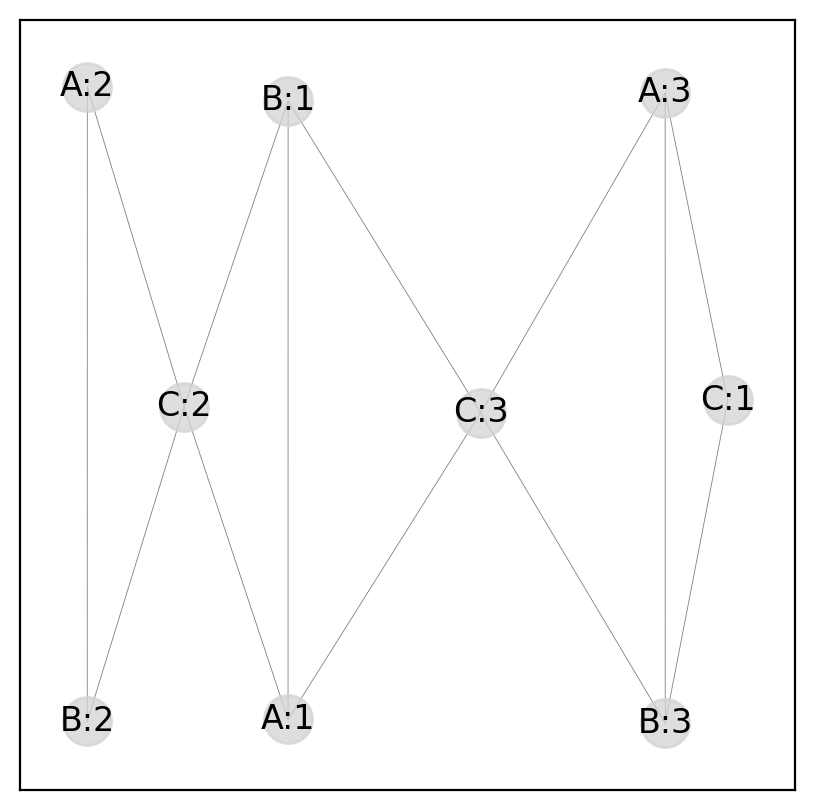

In [54]:
fig,ax = plt.subplots(figsize=(5,5))
nodes_plot = nx.draw_networkx_nodes(
        resin.g, ax=ax, 
        pos=resin.pos_new, 
        node_color="lightgrey",
        alpha=.75, label=False) 
edges_plot = nx.draw_networkx_edges(
resin.g, ax=ax, edge_color="grey", pos=resin.pos_new, width=.3,
)
nx.draw_networkx_labels(resin.g, ax=ax, pos=resin.pos_new)

In [146]:
nx.betweenness_centrality(resin.g)

{'B:1': 0.21428571428571427,
 'C:2': 0.42857142857142855,
 'A:1': 0.21428571428571427,
 'C:3': 0.5357142857142857,
 'A:2': 0.0,
 'B:2': 0.0,
 'C:1': 0.0,
 'A:3': 0.10714285714285714,
 'B:3': 0.10714285714285714}